<a href="https://colab.research.google.com/github/nethmi-i-j/Food-Delivery-Time-Predictor/blob/main/Food_Delivery_Time_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score)

Configuration

In [ ]:
pd.set_option('display.max_columns',None)
pd.set_option('display.float_format',lambda x: f'{x:.3f}')

CSV_PATH = '/content/Food_Delivery_Times.csv'
TARGET_COLUMN = 'Delivery_Time_min'
RANDOM_STATE = 42

Load the dataset

In [ ]:
df = pd.read_csv(CSV_PATH)

In [ ]:
print('Size of the Dataframe :',df.shape)


Size of the Dataframe : (1000, 9)


In [ ]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.930,Windy,Low,Afternoon,Scooter,12,1.000,43
1,738,16.420,Clear,Medium,Evening,Bike,20,2.000,84
2,741,9.520,Foggy,Low,Night,Scooter,28,1.000,59
3,661,7.440,Rainy,Medium,Afternoon,Scooter,5,1.000,37
4,412,19.030,Clear,Low,Morning,Bike,16,5.000,68


In [ ]:
df = df.drop(['Order_ID'], axis=1)
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.930,Windy,Low,Afternoon,Scooter,12,1.000,43
1,16.420,Clear,Medium,Evening,Bike,20,2.000,84
2,9.520,Foggy,Low,Night,Scooter,28,1.000,59
3,7.440,Rainy,Medium,Afternoon,Scooter,5,1.000,37
4,19.030,Clear,Low,Morning,Bike,16,5.000,68


In [ ]:
print('Size of the Dataframe :',df.shape)

Size of the Dataframe : (1000, 8)


## 2. Exploratory Data Analysis

In [ ]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 970 non-null    object 
 2   Traffic_Level           970 non-null    object 
 3   Time_of_Day             970 non-null    object 
 4   Vehicle_Type            1000 non-null   object 
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  970 non-null    float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [ ]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numerical_Columns : ',numerical_columns)
print('Categorical_Columns :',categorical_columns)
print('Target_Column :',TARGET_COLUMN)

Numerical_Columns :  ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
Categorical_Columns : ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
Target_Column : Delivery_Time_min


In [ ]:
# value counts for each category

for col in categorical_columns:
  print('\n', df[col].value_counts())


 Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

 Traffic_Level
Medium    390
Low       383
High      197
Name: count, dtype: int64

 Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

 Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


In [ ]:
for col in df.columns:
  print(f'\n{col} : ',df[col].unique())


Distance_km :  [ 7.93 16.42  9.52  7.44 19.03 19.4  17.39  1.78 10.62 16.86 15.54 10.89
  4.69  2.8   2.17 17.86  2.53  6.58  5.38 15.56 13.08  0.86  5.83 11.2
 14.59 12.91 13.92  4.04 18.05 12.88 19.45  4.58 19.73  2.47 17.8   5.96
 12.85  1.02  6.84  8.68 10.69  0.99  1.11  2.16 13.17  8.79  5.93  2.09
  7.57 10.52  4.83 19.81 10.1   7.64 12.35  5.9   0.9  11.58 16.16 15.51
 12.16  4.96  3.64  2.85 10.4  12.31  3.53 13.6  15.23  4.17  3.21  6.38
 16.54 12.02 11.94  9.08  3.46  6.8  17.38  3.25 10.28 16.14  3.55 10.65
  7.3   7.03 12.43 12.76 11.39 19.41  8.32  1.92  1.15  7.46  7.25 16.7
 17.2  18.76  9.22  2.84 17.59 14.89  1.3  18.99  1.6   8.26 10.16 12.03
 14.73 12.56  5.53 10.18 15.5   2.98 16.69 11.22  8.53 12.49  0.97 12.6
  6.91 18.97  4.05 14.29 12.11 14.94  2.29 17.36 18.48 16.25  5.13 15.81
  0.61  5.55 19.35  4.03  7.09  8.25 11.26 19.7   0.8   7.   14.43  6.89
  1.5   2.78 11.31 15.05  5.78 11.83  8.08 16.1   9.74 17.6  10.22  2.19
 11.41  4.14 12.65  4.15 16.8   9.06 1

In [ ]:
# checking for missing values

print('Missing values count per column : ')
df.isna().sum()

Missing values count per column : 


,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


**Note :**

* 30 missing values in Weather column

* 30 missing values in Traffic_Level column

* 30 missing values in Time_of_Day column

* 30 missing values in Courier_Experience_yrs column

In [ ]:
# checking for duplicate rows

duplicates = df.duplicated()
duplicates_count = duplicates.sum()
print('Number of duplicate rows : ',duplicates_count)

Number of duplicate rows :  0


In [ ]:
# descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Distance_km,1000.000,10.060,5.697,0.590,5.105,10.190,15.018,19.990
Preparation_Time_min,1000.000,16.982,7.205,5.000,11.000,17.000,23.000,29.000
Courier_Experience_yrs,970.000,4.579,2.914,0.000,2.000,5.000,7.000,9.000
Delivery_Time_min,1000.000,56.732,22.071,8.000,41.000,55.500,71.000,153.000


## 3. Data Visualization

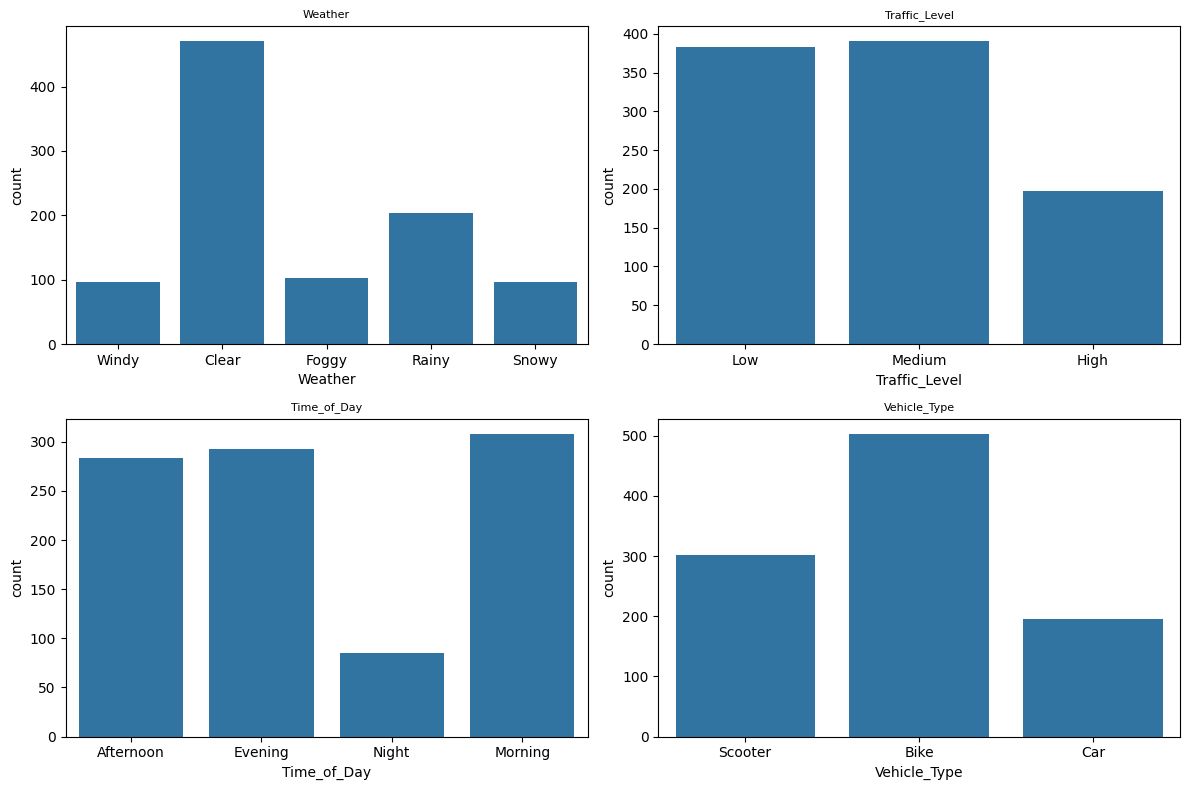

In [ ]:
# countplots for categorical columns

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
  sns.countplot(data=df, x=col, ax=axes[i])
  axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()



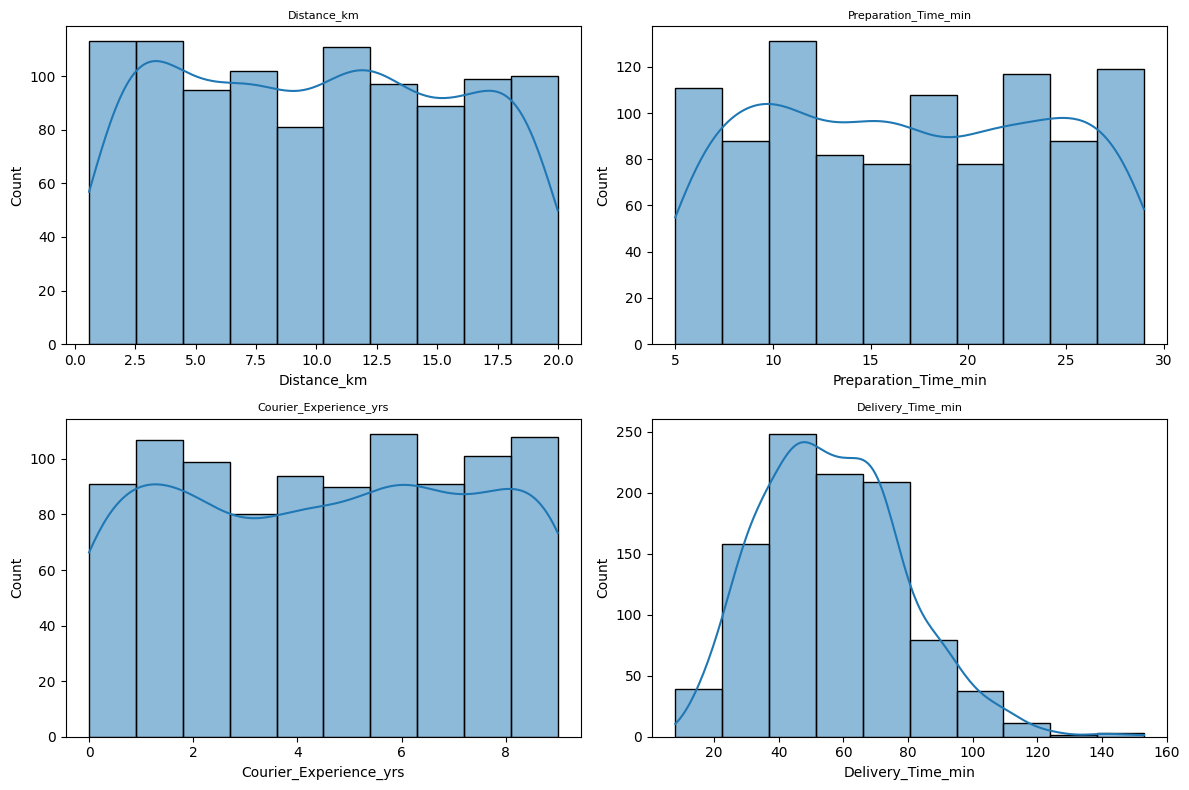

In [ ]:
# histogram plots for numerical variables

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
  sns.histplot(df[col], bins=10, kde=True, ax=axes[i])
  axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

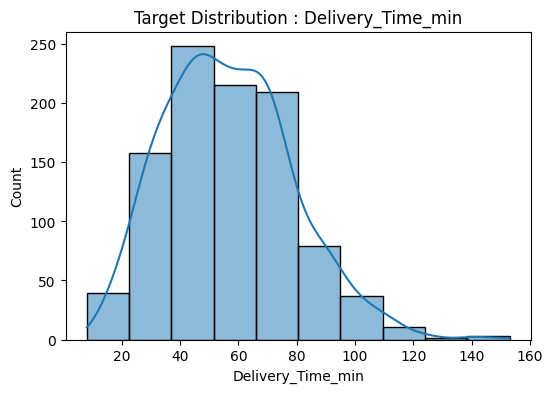

In [ ]:
# distribution of target

plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COLUMN], bins=10, kde=True)
plt.title('Target Distribution : Delivery_Time_min')
plt.xlabel('Delivery_Time_min')
plt.show()

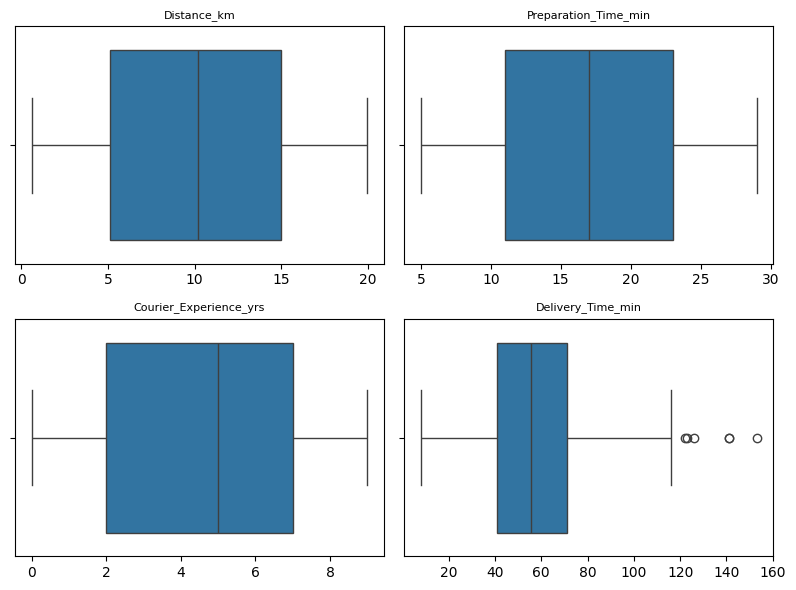

In [ ]:
# outliers analysis - boxplots

fig, axes = plt.subplots(2, 2, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
  sns.boxplot(x=df[col], ax=axes[i])
  axes[i].set_title(col, fontsize=8)
  axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


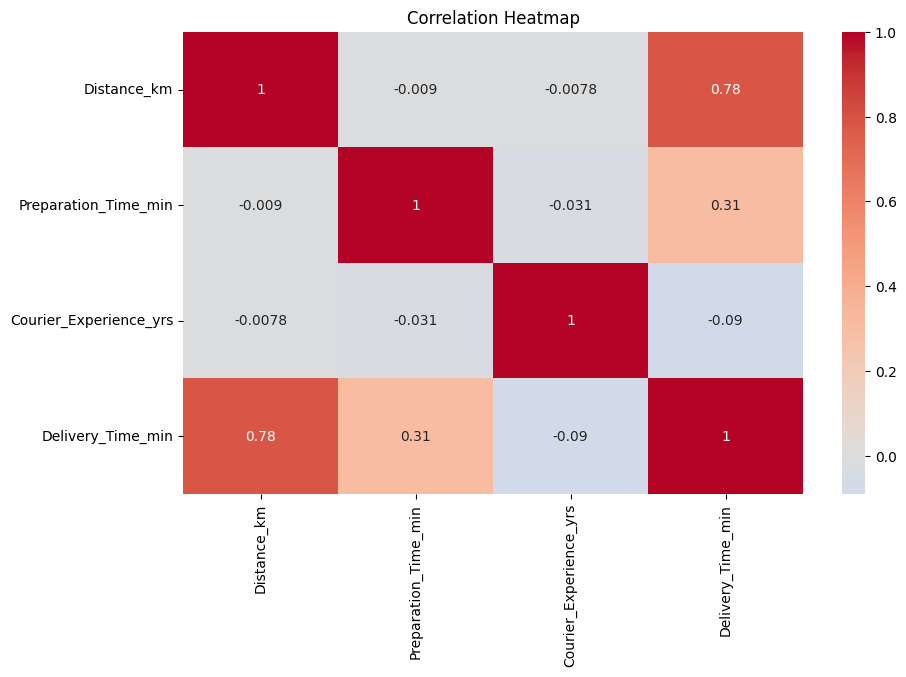

In [ ]:
# relationship between numerical features and target

plt.figure(figsize=(10,6))
sns.heatmap(df[numerical_columns].corr(), cmap='coolwarm', center=0, annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# correlation with target

corr_with_target = df[numerical_columns].corr()[TARGET_COLUMN].sort_values(ascending=False)
print('Correlation with target : ')
print(corr_with_target)

Correlation with target : 
Delivery_Time_min         1.000
Distance_km               0.781
Preparation_Time_min      0.307
Courier_Experience_yrs   -0.090
Name: Delivery_Time_min, dtype: float64


Key insights from EDA




*  Dataset has 4 numeric (Distance_km, Preparation_Time_min, Courier_Experience_yrs, Delivery_Time_min),

    4 categorical features (Weather, Traffic_Level, Time_of_Day, Vehicle_Type).

* Target_Column : Delivery_Time_min

* There are,

    30 missing values in Weather column

    30 missing values in Traffic_Level column

    30 missing values in Time_of_Day column

    30 missing values in Courier_Experience_yrs column

*  Target (Delivery_Time_min) has small skewness.

*  Delivery_Time_min is the storngest predictor(high influence on Delivery_Time_min).



Preprocessing & Evaluation plan

*  Median imputation for numerical missing values.

* Mode imputation for categorical missing values.

*  one-hot encoding for categorical features.

*  Feature scaling for linear models.

*  Use pipelines to avoid data leakage.

*  Baseline model ---> cross validation(CV)---> model selection ---> hyperparameter tuning.

*  primary metric: RMSE (Root Mean Squared Error), secondary: MAE (Mean Absolute Error) and R^2.

*  Final evaluation only on test set.

## 4. Data Preprocessing

In [ ]:
X = df.drop(columns=[TARGET_COLUMN])
Y = df[TARGET_COLUMN]

In [ ]:
X.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.930,Windy,Low,Afternoon,Scooter,12,1.000
1,16.420,Clear,Medium,Evening,Bike,20,2.000
2,9.520,Foggy,Low,Night,Scooter,28,1.000
3,7.440,Rainy,Medium,Afternoon,Scooter,5,1.000
4,19.030,Clear,Low,Morning,Bike,16,5.000


In [ ]:
Y.head()

,Delivery_Time_min
0,43
1,84
2,59
3,37
4,68


In [ ]:
# train test split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=RANDOM_STATE)

In [ ]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(1000, 7)
(900, 7)
(100, 7)


Preprocessing Pipeline

In [ ]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numerical_features :', numerical_features)
print('Categorical_features :', categorical_features)

# preprocessing - numerical features
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())

    ]
)

# preprocessing - categorical features
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))

    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)




Numerical_features : ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
Categorical_features : ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


## 5. Model Selection

Baseline Model

In [ ]:
baseline_pipe = Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',LinearRegression())
    ]
)

In [ ]:
baseline_pipe.fit(X_train, Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Distance_km',
                                                   'Preparation_Time_min',
                                                   'Courier_Experience_yrs']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weather', 'Traffic_Level',
                                                   'Time_of_Day',
                                                   'Vehicle_Type'])])),
                ('model', LinearRegression())])

In [ ]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [ ]:
train_baseline_rmse = root_mean_squared_error(Y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(Y_train, train_baseline_pred)
train_baseline_r2 = r2_score(Y_train, train_baseline_pred)

print('===Train Baseline Metrics===')
print('RMSE : ',train_baseline_rmse)
print('MAE : ',train_baseline_mae)
print('r2 : ',train_baseline_r2)

===Train Baseline Metrics===
RMSE :  10.461522512782476
MAE :  6.3786842947451525
r2 :  0.7754233588304866


In [ ]:
test_baseline_rmse = root_mean_squared_error(Y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(Y_test, test_baseline_pred)
test_baseline_r2 = r2_score(Y_test, test_baseline_pred)

print('===Test Baseline Metrics===')
print('RMSE : ',test_baseline_rmse)
print('MAE : ',test_baseline_mae)
print('r2 : ',test_baseline_r2)

===Test Baseline Metrics===
RMSE :  10.481584988778353
MAE :  6.767049629927542
r2 :  0.7709492411052206


Model selection and optimization

In [ ]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE, max_iter=10000),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

In [ ]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

In [ ]:
rows = []

for name, model in models.items():
  pipe = Pipeline(
      steps=[
          ('preprocess', preprocess),
          ('model',model)
      ]
  )

  scores = cross_validate(pipe, X_train, Y_train, scoring=scoring, n_jobs=1)

  rows.append({
      'model':name,
      'cv_rmse':-scores['test_rmse'].mean(),
      'cv_mae':-scores['test_mae'].mean(),
      'cv_r2':scores['test_r2'].mean()

  })

  #sort based on lowest rmse values

  cv_results = pd.DataFrame(rows).sort_values('cv_rmse')
  print('=== CVModel Comparison ===')
  print(cv_results)

=== CVModel Comparison ===
              model  cv_rmse  cv_mae  cv_r2
0  LinearRegression   10.533   6.501  0.764
=== CVModel Comparison ===
              model  cv_rmse  cv_mae  cv_r2
1             Ridge   10.532   6.501  0.764
0  LinearRegression   10.533   6.501  0.764
=== CVModel Comparison ===
              model  cv_rmse  cv_mae  cv_r2
1             Ridge   10.532   6.501  0.764
0  LinearRegression   10.533   6.501  0.764
2             Lasso   11.299   7.453  0.730
=== CVModel Comparison ===
              model  cv_rmse  cv_mae  cv_r2
1             Ridge   10.532   6.501  0.764
0  LinearRegression   10.533   6.501  0.764
2             Lasso   11.299   7.453  0.730
3      RandomForest   11.845   7.752  0.701
=== CVModel Comparison ===
              model  cv_rmse  cv_mae  cv_r2
1             Ridge   10.532   6.501  0.764
0  LinearRegression   10.533   6.501  0.764
4  GradientBoosting   11.264   7.120  0.730
2             Lasso   11.299   7.453  0.730
3      RandomForest   11.845 

In [ ]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
1,Ridge,10.532,6.501,0.764
0,LinearRegression,10.533,6.501,0.764
4,GradientBoosting,11.264,7.120,0.730
2,Lasso,11.299,7.453,0.730
3,RandomForest,11.845,7.752,0.701


In [ ]:
best_row = cv_results.sort_values('cv_rmse').iloc[0]
best_model_name = best_row['model']
best_rmse = best_row['cv_rmse']

print('Best model based on CV RMSE : ')
print('Model : ',best_model_name)
print('CV RMSE : ',best_rmse)

Best model based on CV RMSE : 
Model :  Ridge
CV RMSE :  10.53225939767433


In [ ]:
lr_pipe = Pipeline(
    steps=[
        ('preprocessing', preprocess),
        ('model',Ridge())
    ]
)

Hyperparameter Tuning

In [ ]:
param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

In [ ]:
grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [ ]:
grid.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min',
                                                                          'Courier_Experience_yrs']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type'])])),
                                       ('model', Ridge())]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print('====Tuned Ridge (CV) ====')
print('Best CV RMSE : ', -grid.best_score_)
print('Best parameters : ',grid.best_params_)

====Tuned Ridge (CV) ====
Best CV RMSE :  10.581278911424087
Best parameters :  {'model__alpha': 10}


Retraining with best parameters

In [ ]:
rg_best = Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',Ridge(alpha = 10))


    ]
)

In [ ]:
rg_best.fit(X_train, Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Distance_km',
                                                   'Preparation_Time_min',
                                                   'Courier_Experience_yrs']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weather', 'Traffic_Level',
                                                   'Time_of_Day',
                                                   'Vehicle_Type'])])),
                ('model', Ridge(alpha=10))])

## 6. Final Evaluation

In [ ]:
train_final_pred = rg_best.predict(X_train)

train_final_rmse = root_mean_squared_error(Y_train, train_final_pred)
train_final_mae = mean_absolute_error(Y_train, train_final_pred)
train_final_r2 = r2_score(Y_train, train_final_pred)

print('===Final Model (Tuned Ridge) Train Performance===')
print(f'RMSE : {train_final_rmse:.3f}')
print(f'MAE : {train_final_mae:.3f}')
print(f'r2 : {train_final_r2:.3f}')

===Final Model (Tuned Ridge) Train Performance===
RMSE : 10.467
MAE : 6.398
r2 : 0.775


In [ ]:
test_final_pred = rg_best.predict(X_test)

test_final_rmse = root_mean_squared_error(Y_test, test_final_pred)
test_final_mae = mean_absolute_error(Y_test, test_final_pred)
test_final_r2 = r2_score(Y_test, test_final_pred)

print('===Final Model (Tuned Ridge) Test Performance===')
print(f'RMSE : {test_final_rmse:.3f}')
print(f'MAE : {test_final_mae:.3f}')
print(f'r2 : {test_final_r2:.3f}')

===Final Model (Tuned Ridge) Test Performance===
RMSE : 10.535
MAE : 6.844
r2 : 0.769


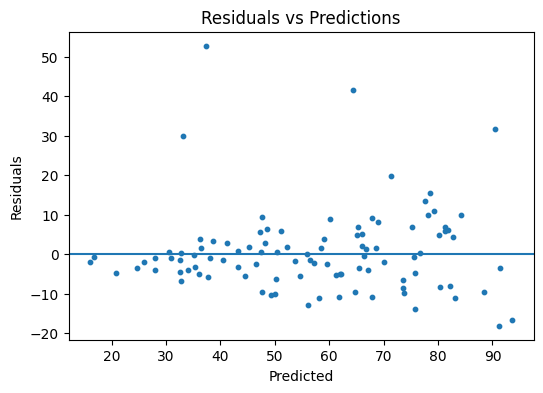

In [ ]:
# rsidual plot

residuals = Y_test - test_final_pred

plt.figure(figsize=(6,4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title('Residuals vs Predictions')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()



## 7. Save and Download the model

In [ ]:
import joblib

# Save the trained pipeline
MODEL_PATH = 'Food_delivery_ridge_model.joblib'
joblib.dump(rg_best, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')


Model saved to Food_delivery_ridge_model.joblib


In [ ]:
# Verify the saved model

loaded_model = joblib.load(MODEL_PATH)


Predictive System

In [ ]:
def predict_delivery_time(
    distance_km,
    preparation_time_min,
    courier_experience_yrs,
    weather,
    traffic_level,
    time_of_day,
    vehicle_type
):
    input_data = pd.DataFrame([{
        'Distance_km': distance_km,
        'Preparation_Time_min': preparation_time_min,
        'Courier_Experience_yrs': courier_experience_yrs,
        'Weather': weather,
        'Traffic_Level': traffic_level,
        'Time_of_Day': time_of_day,
        'Vehicle_Type': vehicle_type
    }])

    prediction = loaded_model.predict(input_data)
    predict_time =  round(prediction[0], 2)
    print(f'Predicted Delivery Time: {predict_time} minutes')




In [ ]:
predict_delivery_time(
    distance_km=5.0,
    preparation_time_min=10,
    courier_experience_yrs=3,
    weather='Clear',
    traffic_level='Medium',
    time_of_day='Evening',
    vehicle_type='Bike'
)

Predicted Delivery Time: 35.47 minutes
